# WEEK 4 : DELAY INTELLIGENCE & RISK ANALYSIS

Import Libraries

In [31]:


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)



Load Dataset

In [32]:
df=pd.read_csv("../data/processed/week2_processed.csv")

df_time=df.dropna(
subset=["Month_Name",
"Departure_DayOfWeek"])

Label Function

In [33]:
def add_labels(ax, total=None):

    for p in ax.patches:
        value = p.get_height()

        if total:
            label = f"{int(value)} ({value/total*100:.1f}%)"
        else:
            label = f"{int(value)}"

        ax.annotate(
            label,
            (p.get_x() + p.get_width()/2, value),
            ha="center",
            va="bottom",
            fontsize=9
        )

OVERALL DELAY KPI

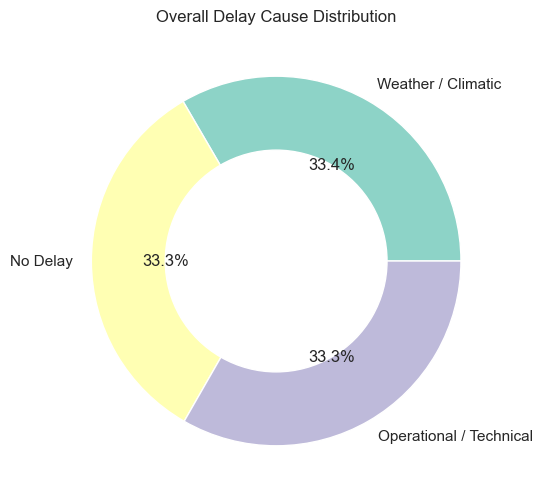

In [34]:
delay_counts=df["Delay_Cause"].value_counts()

plt.pie(
delay_counts,
labels=delay_counts.index,
autopct="%1.1f%%",
colors=sns.color_palette("Set3"),
wedgeprops={"width":0.4})

plt.title("Overall Delay Cause Distribution")
plt.show()

Operational Risk

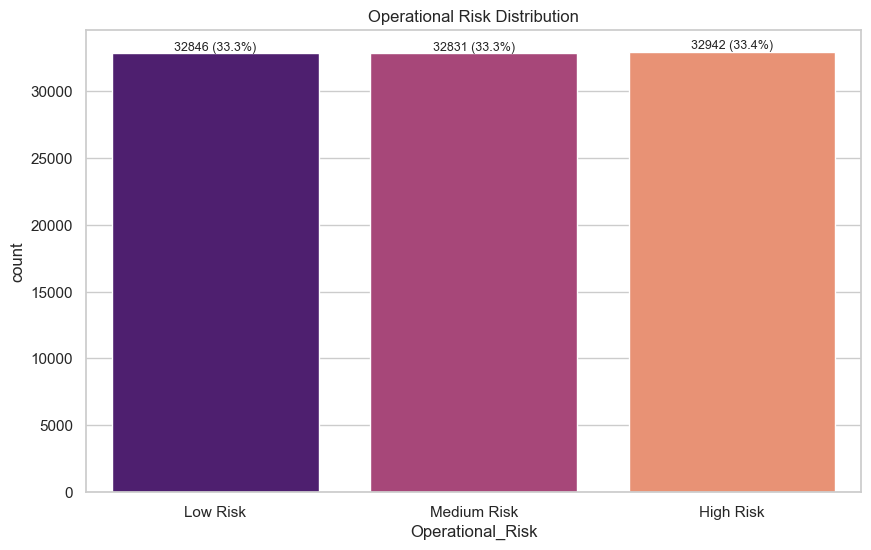

In [35]:
ax = sns.countplot(
    x="Operational_Risk",
    data=df,
    palette="magma",
    hue='Operational_Risk',
    legend=False
)

plt.title("Operational Risk Distribution")

add_labels(ax, len(df))

plt.show()

Delay Cause vs Flight Type

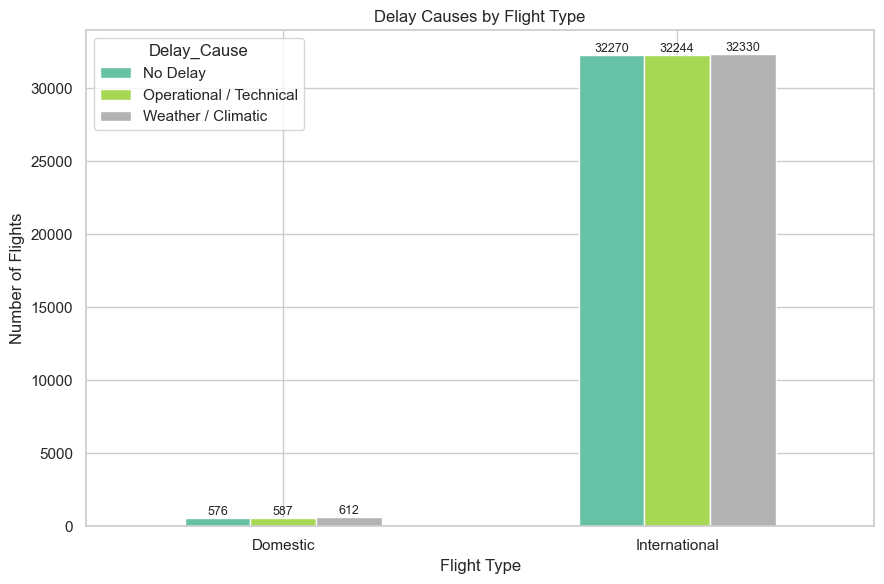

In [36]:
cause_type = pd.crosstab(
    df["Flight_Type"],
    df["Delay_Cause"]
)

ax = cause_type.plot(
    kind="bar",
    figsize=(9,6),
    colormap="Set2"
)

plt.title("Delay Causes by Flight Type")
plt.xlabel("Flight Type")
plt.ylabel("Number of Flights")
plt.xticks(rotation=0)

# ----- ADD LABELS -----
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.tight_layout()
plt.show()

Geographic Delay Analysis

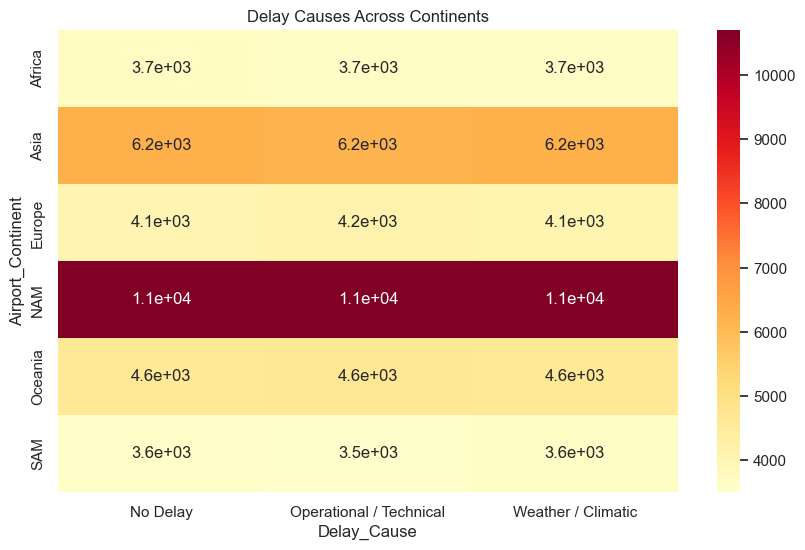

In [37]:
sns.heatmap(
pd.crosstab(
df["Airport_Continent"],
df["Delay_Cause"]),
annot=True,
cmap="YlOrRd")

plt.title("Delay Causes Across Continents")
plt.show()

TEMPORAL INTELLIGENCE

Monthly Delay

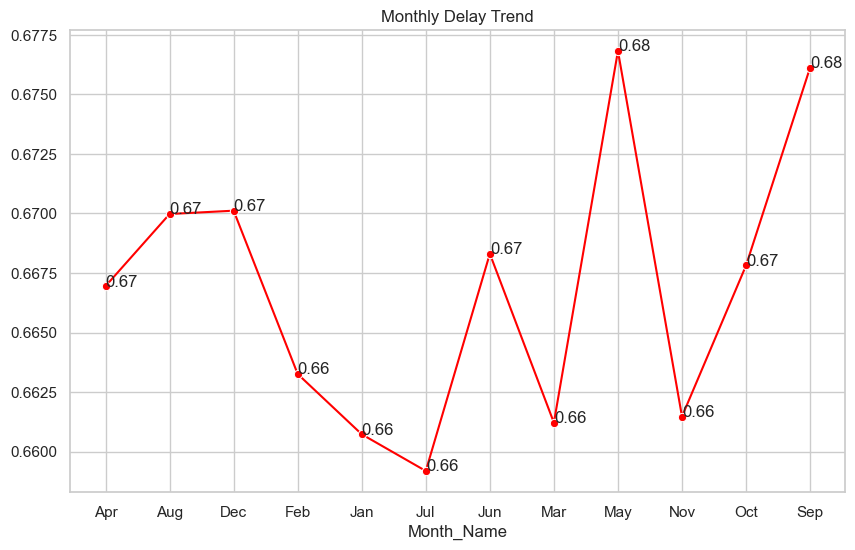

In [38]:
monthly = df_time.groupby(
    "Month_Name"
)["Is_Flight_Delayed"].mean()

ax = sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker="o",
    color="red"
)

for x,y in zip(monthly.index, monthly.values):
    plt.text(x, y, f"{y:.2f}")

plt.title("Monthly Delay Trend")
plt.show()

Rolling Average Trend

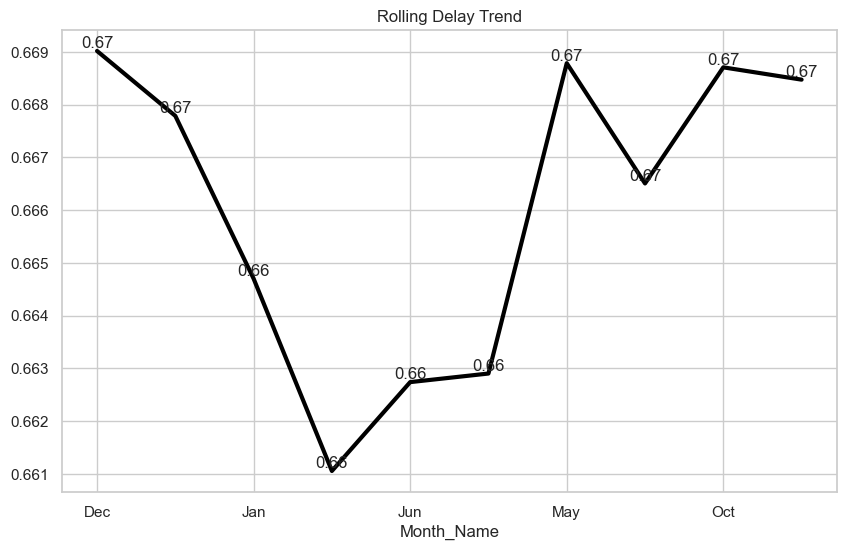

In [39]:
rolling = monthly.rolling(3).mean()

ax = rolling.plot(
    linewidth=3,
    color="black"
)

for i, y in enumerate(rolling.values):
    if pd.notna(y):
        ax.text(i, y, f"{y:.2f}", ha="center", va="bottom")

plt.title("Rolling Delay Trend")

plt.show()

Weekly Delay Probability

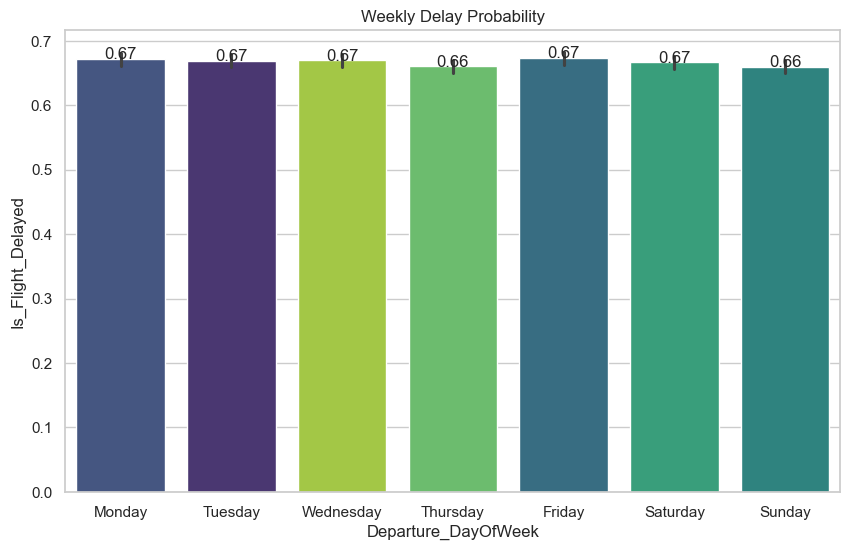

In [40]:


day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

ax = sns.barplot(
    x="Departure_DayOfWeek",
    y="Is_Flight_Delayed",
    data=df_time,
    palette="viridis",
    hue="Departure_DayOfWeek",
    order=day_order,     
    legend=False
)

plt.title("Weekly Delay Probability")

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha="center"
    )

plt.show()

### Week 4 Insights

- Operational and climatic factors drive flight disruptions.
- International operations carry higher uncertainty.
- Seasonal demand increases delay probability.